#Import Library

In [ ]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

#Data Collection

In [ ]:
def Break(title: str, emoji: str = "⚙️", ch: str = "=", n: int = 72):
    print("\n")
    print(ch * n)
    print(f"{emoji} {title.upper()}")
    print(ch * n)

In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("dionisiusdh/covid19-indonesian-twitter-sentiment")

print("Path to dataset files:", path)

files_in_dir = os.listdir(path)
csv_files = [f for f in files_in_dir if f.endswith('.csv')]

if not csv_files:
    raise FileNotFoundError("No CSV file found in the downloaded directory.")

csv_file_name = csv_files[0]
full_csv_path = os.path.join(path, csv_file_name)

df = pd.read_csv(full_csv_path)
df.head()

Using Colab cache for faster access to the 'covid19-indonesian-twitter-sentiment' dataset.
Path to dataset files: /kaggle/input/covid19-indonesian-twitter-sentiment


,conversation_id,date,time,user_id,username,tweet,mentions,replies_count,retweets_count,likes_count,hashtags
0,1258425982907637761,2020-05-07,23:58:29,1058474317,monologis_id,https://bit.ly/2L6CcbB | Seharusnya saat ini...,[],0,3,0,[]
1,1258320972198940675,2020-05-07,23:57:30,1179769476,its_dul,Klo kata gw Pemerintah tuh lagi menerapkan Her...,['mas__piyuuu'],0,0,0,[]
2,1258356644427083777,2020-05-07,23:53:20,1012156669831229441,meonkbaong,Saat ini yang bisa saya lakukan hanya menyiapk...,['oiivert'],0,0,0,[]
3,1258424368993931265,2020-05-07,23:52:04,1204303690061844481,rakyatdotnews,"Satu Warga Positif Corona, Bupati: Kondisi ini...",[],0,0,0,"['#rakyatdotnews', '#referensiterkini', '#raky..."
4,1258423545698246656,2020-05-07,23:48:48,227620381,annisathalib_,"emosi bgt, lg kondisi begini gue disuruh liput...",[],0,0,0,['#dirumahaja']


#Data Preprocessing

In [ ]:
Break("Data Info")
print(df.info())
Break("Duplicate Data")
print(df.duplicated().sum())
Break("Missing Value")
print(df.isnull().sum().sum())



⚙️ DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52959 entries, 0 to 52958
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   conversation_id  52959 non-null  int64 
 1   date             52959 non-null  object
 2   time             52959 non-null  object
 3   user_id          52959 non-null  int64 
 4   username         52959 non-null  object
 5   tweet            52959 non-null  object
 6   mentions         52959 non-null  object
 7   replies_count    52959 non-null  int64 
 8   retweets_count   52959 non-null  int64 
 9   likes_count      52959 non-null  int64 
 10  hashtags         52959 non-null  object
dtypes: int64(5), object(6)
memory usage: 4.4+ MB
None


⚙️ DUPLICATE DATA
3320


⚙️ MISSING VALUE
0


##Hapus Duplikat

In [ ]:
df.drop_duplicates(subset=['conversation_id'], inplace=True)

Break("Data Info")
print(df.info())
Break("Duplicate Data")
print(df.duplicated().sum())



⚙️ DATA INFO
<class 'pandas.core.frame.DataFrame'>
Index: 45949 entries, 0 to 52957
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   conversation_id  45949 non-null  int64 
 1   date             45949 non-null  object
 2   time             45949 non-null  object
 3   user_id          45949 non-null  int64 
 4   username         45949 non-null  object
 5   tweet            45949 non-null  object
 6   mentions         45949 non-null  object
 7   replies_count    45949 non-null  int64 
 8   retweets_count   45949 non-null  int64 
 9   likes_count      45949 non-null  int64 
 10  hashtags         45949 non-null  object
dtypes: int64(5), object(6)
memory usage: 4.2+ MB
None


⚙️ DUPLICATE DATA
0


In [ ]:
tweet_df = df['tweet'].copy()

##Case Folding

In [ ]:
original_tweet_df = df['tweet'].copy()
tweet_df = tweet_df.str.lower()

comparison_df = pd.DataFrame({
    'Original Tweet': original_tweet_df,
    'Case Folded Tweet': tweet_df
})

Break("Data Head with Case Folding Comparison")
display(comparison_df.head())



⚙️ DATA HEAD WITH CASE FOLDING COMPARISON


,Original Tweet,Case Folded Tweet
0,https://bit.ly/2L6CcbB | Seharusnya saat ini...,https://bit.ly/2l6ccbb | seharusnya saat ini...
1,Klo kata gw Pemerintah tuh lagi menerapkan Her...,klo kata gw pemerintah tuh lagi menerapkan her...
2,Saat ini yang bisa saya lakukan hanya menyiapk...,saat ini yang bisa saya lakukan hanya menyiapk...
3,"Satu Warga Positif Corona, Bupati: Kondisi ini...","satu warga positif corona, bupati: kondisi ini..."
4,"emosi bgt, lg kondisi begini gue disuruh liput...","emosi bgt, lg kondisi begini gue disuruh liput..."


##Penghapusan karakter tidak relevan

In [ ]:
import re

def clean_tweet_text(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove mentions (@username)
    text = re.sub(r'@\w+', '', text)
    # Remove hashtags (#hashtag)
    text = re.sub(r'#\w+', '', text)
    # Remove punctuation and numbers (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

cleaned_tweet_df = tweet_df.apply(clean_tweet_text)

comparison_df_cleaned = pd.DataFrame({
    'Case Folded Tweet': tweet_df,
    'Cleaned Tweet': cleaned_tweet_df
})

Break("Data Head with Cleaned Tweet Comparison")
display(comparison_df_cleaned.head())



⚙️ DATA HEAD WITH CLEANED TWEET COMPARISON


,Case Folded Tweet,Cleaned Tweet
0,https://bit.ly/2l6ccbb | seharusnya saat ini...,seharusnya saat ini pemerintah lampung bisa me...
1,klo kata gw pemerintah tuh lagi menerapkan her...,klo kata gw pemerintah tuh lagi menerapkan her...
2,saat ini yang bisa saya lakukan hanya menyiapk...,saat ini yang bisa saya lakukan hanya menyiapk...
3,"satu warga positif corona, bupati: kondisi ini...",satu warga positif corona bupati kondisi ini m...
4,"emosi bgt, lg kondisi begini gue disuruh liput...",emosi bgt lg kondisi begini gue disuruh liputa...


##Reduksi pengulangan huruf

In [ ]:
def reduce_repeated_chars(text):
    # Replace any character repeated 3 or more times with a single instance of that character
    # e.g., 'heeeellooo' -> 'helo'
    return re.sub(r'(.)\1{2,}', r'\1', text)

reduced_tweet_df = cleaned_tweet_df.apply(reduce_repeated_chars)

comparison_df_reduced = pd.DataFrame({
    'Cleaned Tweet': cleaned_tweet_df,
    'Reduced Repetition Tweet': reduced_tweet_df
})

Break("Data Head with Reduced Repetition Tweet Comparison")
display(comparison_df_reduced.head())



⚙️ DATA HEAD WITH REDUCED REPETITION TWEET COMPARISON


,Cleaned Tweet,Reduced Repetition Tweet
0,seharusnya saat ini pemerintah lampung bisa me...,seharusnya saat ini pemerintah lampung bisa me...
1,klo kata gw pemerintah tuh lagi menerapkan her...,klo kata gw pemerintah tuh lagi menerapkan her...
2,saat ini yang bisa saya lakukan hanya menyiapk...,saat ini yang bisa saya lakukan hanya menyiapk...
3,satu warga positif corona bupati kondisi ini m...,satu warga positif corona bupati kondisi ini m...
4,emosi bgt lg kondisi begini gue disuruh liputa...,emosi bgt lg kondisi begini gue disuruh liputa...


##Normalisasi teks

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
import requests
import io
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt', quiet=True)

def download_slang_dict(url):
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = io.StringIO(response.text)
        slang_df = pd.read_csv(data)
        slang_dict = dict(zip(slang_df['slang'], slang_df['formal']))
        print("Slang dictionary downloaded and loaded successfully.")
        return slang_dict
    except requests.exceptions.RequestException as e:
        print(f"Error downloading slang dictionary: {e}")
        return None
    except Exception as e:
        print(f"Error processing slang dictionary: {e}")
        return None

slang_url = "https://raw.githubusercontent.com/nasalsabila/kamus-alay/c710fa9f3f8d8727c24f3209f4f6a4b6ecaf6d8b/colloquial-indonesian-lexicon.csv"
slang_dictionary = download_slang_dict(slang_url)

def normalize_slang(text, slang_dict):
    if slang_dict is None:
        return text
    tokens = word_tokenize(text)
    normalized_tokens = [slang_dict.get(word, word) for word in tokens]
    return ' '.join(normalized_tokens)

if slang_dictionary:
    normalized_tweet_df = reduced_tweet_df.apply(lambda x: normalize_slang(x, slang_dictionary))
else:
    print("Slang normalization skipped due to dictionary download failure.")
    normalized_tweet_df = reduced_tweet_df.copy()

comparison_df_normalized = pd.DataFrame({
    'Reduced Repetition Tweet': reduced_tweet_df,
    'Normalized Tweet': normalized_tweet_df
})

Break("Data Head with Slang Normalization Comparison")
display(comparison_df_normalized.head())

Slang dictionary downloaded and loaded successfully.


⚙️ DATA HEAD WITH SLANG NORMALIZATION COMPARISON


,Reduced Repetition Tweet,Normalized Tweet
0,seharusnya saat ini pemerintah lampung bisa me...,seharusnya saat ini pemerintah lampung bisa me...
1,klo kata gw pemerintah tuh lagi menerapkan her...,kalo kata gue pemerintah tuh lagi menerapkan h...
2,saat ini yang bisa saya lakukan hanya menyiapk...,saat ini yang bisa saya lakukan hanya menyiapk...
3,satu warga positif corona bupati kondisi ini m...,satu warga positif corona bupati kondisi ini m...
4,emosi bgt lg kondisi begini gue disuruh liputa...,emosi banget lagi kondisi begini gue disuruh l...


##Tokenizing

In [ ]:
def tokenize_text(text):
    return word_tokenize(text)

tokenized_tweet_df = normalized_tweet_df.apply(tokenize_text)

comparison_df_tokenized = pd.DataFrame({
    'Normalized Tweet': normalized_tweet_df,
    'Tokenized Tweet': tokenized_tweet_df
})

Break("Data Head with Tokenized Tweet Comparison")
display(comparison_df_tokenized.head())



⚙️ DATA HEAD WITH TOKENIZED TWEET COMPARISON


,Normalized Tweet,Tokenized Tweet
0,seharusnya saat ini pemerintah lampung bisa me...,"[seharusnya, saat, ini, pemerintah, lampung, b..."
1,kalo kata gue pemerintah tuh lagi menerapkan h...,"[kalo, kata, gue, pemerintah, tuh, lagi, mener..."
2,saat ini yang bisa saya lakukan hanya menyiapk...,"[saat, ini, yang, bisa, saya, lakukan, hanya, ..."
3,satu warga positif corona bupati kondisi ini m...,"[satu, warga, positif, corona, bupati, kondisi..."
4,emosi banget lagi kondisi begini gue disuruh l...,"[emosi, banget, lagi, kondisi, begini, gue, di..."


##Filtering

In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

# Get Indonesian stopwords
id_stopwords = set(stopwords.words('indonesian'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in id_stopwords]

filtered_tweet_df = tokenized_tweet_df.apply(remove_stopwords)

comparison_df_filtered = pd.DataFrame({
    'Tokenized Tweet': tokenized_tweet_df,
    'Filtered Tweet': filtered_tweet_df
})

Break("Data Head with Stopwords Removal Comparison")
display(comparison_df_filtered.head())



⚙️ DATA HEAD WITH STOPWORDS REMOVAL COMPARISON


,Tokenized Tweet,Filtered Tweet
0,"[seharusnya, saat, ini, pemerintah, lampung, b...","[pemerintah, lampung, bantuan, mahasiswa, dera..."
1,"[kalo, kata, gue, pemerintah, tuh, lagi, mener...","[kalo, gue, pemerintah, tuh, menerapkan, herd,..."
2,"[saat, ini, yang, bisa, saya, lakukan, hanya, ...","[lakukan, makanan, berbuka, sahur, kepala, kel..."
3,"[satu, warga, positif, corona, bupati, kondisi...","[warga, positif, corona, bupati, kondisi, menu..."
4,"[emosi, banget, lagi, kondisi, begini, gue, di...","[emosi, banget, kondisi, gue, disuruh, liputan..."


##Stemming

In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.4 MB/s eta 0:00:00


In [ ]:
!pip install swifter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for swifter: filename=swifter-1.4.0-py3-none-any.whl size=16505 sha256=f4a655c56413795d41f33be8fa2366c059dde0ecb906e89bd244f556285f5dea
  Stored in directory: /root/.cache/pip/wheels/d9/31/ff/ff51141a088571a9f672449e5aad5ea8bb35ca5d95ba135f30
Successfully built swifter


In [ ]:
import swifter
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Create stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_tokens(tokens):
    if isinstance(tokens, list):
        return [stemmer.stem(token) for token in tokens]
    return []

stemmed_tweet_df = filtered_tweet_df.swifter.apply(stem_tokens)

comparison_df_stemmed = pd.DataFrame({
    'Filtered Tweet': filtered_tweet_df,
    'Stemmed Tweet': stemmed_tweet_df
})

Break("Data Head with Stemming Comparison")
display(comparison_df_stemmed.head())

# Simpan hasil stemming sebagai checkpoint
stemmed_tweet_df.to_csv('stemmed_tweets_checkpoint.csv', index=False)
print("Dataframe stemmed_tweet_df berhasil disimpan sebagai 'stemmed_tweets_checkpoint.csv'")

Pandas Apply:   0%|          | 0/45949 [00:00<?, ?it/s]



⚙️ DATA HEAD WITH STEMMING COMPARISON


,Filtered Tweet,Stemmed Tweet
0,"[pemerintah, lampung, bantuan, mahasiswa, dera...","[perintah, lampung, bantu, mahasiswa, deras, d..."
1,"[kalo, gue, pemerintah, tuh, menerapkan, herd,...","[kalo, gue, perintah, tuh, terap, herd, immuni..."
2,"[lakukan, makanan, berbuka, sahur, kepala, kel...","[laku, makan, buka, sahur, kepala, keluarga, d..."
3,"[warga, positif, corona, bupati, kondisi, menu...","[warga, positif, corona, bupati, kondisi, tunt..."
4,"[emosi, banget, kondisi, gue, disuruh, liputan...","[emosi, banget, kondisi, gue, suruh, liput, co..."


Dataframe stemmed_tweet_df berhasil disimpan sebagai 'stemmed_tweets_checkpoint.csv'


#Labelling

In [ ]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 69.3 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("text-classification", model="Aardiiiiy/indobertweet-base-Indonesian-sentiment-analysis")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/994 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

In [ ]:
# Load model directly
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("Aardiiiiy/indobertweet-base-Indonesian-sentiment-analysis")
model = AutoModelForSequenceClassification.from_pretrained("Aardiiiiy/indobertweet-base-Indonesian-sentiment-analysis")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
import swifter
import pandas as pd
import os
import ast

csv_filename = 'stemmed_tweets_checkpoint.csv'

final_stemmed_tweet_series = None

if os.path.exists(csv_filename):
    print(f"Loading stemmed tweets from '{csv_filename}'...")
    try:
        loaded_series_str = pd.read_csv(csv_filename, header=None, skiprows=1).iloc[:, 0]
        final_stemmed_tweet_series = loaded_series_str.apply(ast.literal_eval)

        if len(final_stemmed_tweet_series) == len(df):
            final_stemmed_tweet_series.index = df.index
            print("Stemmed tweets loaded successfully from CSV.")
        else:
            print(f"Warning: Loaded stemmed_tweet_df has {len(final_stemmed_tweet_series)} rows, but main df has {len(df)} rows. Attempting to reindex.")
            final_stemmed_tweet_series = final_stemmed_tweet_series.reindex(df.index, fill_value=[])

    except Exception as e:
        print(f"Error loading or processing '{csv_filename}': {e}")
        print("Falling back to assuming 'stemmed_tweet_df' is defined from previous cells.")
        if 'stemmed_tweet_df' in globals():
            final_stemmed_tweet_series = globals()['stemmed_tweet_df']
        else:
            raise RuntimeError("stemmed_tweet_df is neither found in memory nor successfully loaded from CSV.")
else:
    print(f"Stemmed tweets checkpoint file '{csv_filename}' not found. Assuming 'stemmed_tweet_df' is defined from previous cells.")
    if 'stemmed_tweet_df' in globals():
        final_stemmed_tweet_series = globals()['stemmed_tweet_df']
    else:
        raise RuntimeError("stemmed_tweet_df is neither found in memory nor successfully loaded from CSV. Please run stemming cell 'eX-wodOh4x2H' or ensure CSV exists.")

stemmed_tweet_df = final_stemmed_tweet_series

Break("Preparing Stemmed Tweets for Sentiment Analysis")

if 'stemmed_tokens' not in df.columns:
    df['stemmed_tokens'] = stemmed_tweet_df

df['processed_text_for_sentiment'] = df['stemmed_tokens'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) and x else ''
)

print("Sample of processed text for sentiment analysis:")
display(df[['tweet', 'stemmed_tokens', 'processed_text_for_sentiment']].head())

Break("Performing Sentiment Analysis (This might take a while)")

def get_sentiment_label(text):
    if not isinstance(text, str):
        return "error_non_string_input"

    if not text.strip():
        return "neutral"
    try:
        result = pipe(text)[0]
        return result['label']
    except Exception as e:
        return "error"

df['sentiment_label'] = df['processed_text_for_sentiment'].swifter.apply(get_sentiment_label)

Break("Sentiment Analysis Results")

print("Sample of Original Tweet, Processed Text, and Sentiment Label:")
display(df[['tweet', 'processed_text_for_sentiment', 'sentiment_label']].head())

print("\nSentiment Label Distribution:")
print(df['sentiment_label'].value_counts())

Loading stemmed tweets from 'stemmed_tweets_checkpoint.csv'...
Stemmed tweets loaded successfully from CSV.


⚙️ PREPARING STEMMED TWEETS FOR SENTIMENT ANALYSIS
Sample of processed text for sentiment analysis:


,tweet,stemmed_tokens,processed_text_for_sentiment
0,https://bit.ly/2L6CcbB | Seharusnya saat ini...,"[perintah, lampung, bantu, mahasiswa, deras, d...",perintah lampung bantu mahasiswa deras donasi ...
1,Klo kata gw Pemerintah tuh lagi menerapkan Her...,"[kalo, gue, perintah, tuh, terap, herd, immuni...",kalo gue perintah tuh terap herd immunity mamp...
2,Saat ini yang bisa saya lakukan hanya menyiapk...,"[laku, makan, buka, sahur, kepala, keluarga, d...",laku makan buka sahur kepala keluarga dampak c...
3,"Satu Warga Positif Corona, Bupati: Kondisi ini...","[warga, positif, corona, bupati, kondisi, tunt...",warga positif corona bupati kondisi tuntut sam...
4,"emosi bgt, lg kondisi begini gue disuruh liput...","[emosi, banget, kondisi, gue, suruh, liput, co...",emosi banget kondisi gue suruh liput covid dos...




⚙️ PERFORMING SENTIMENT ANALYSIS (THIS MIGHT TAKE A WHILE)


Pandas Apply:   0%|          | 0/45949 [00:00<?, ?it/s]



⚙️ SENTIMENT ANALYSIS RESULTS
Sample of Original Tweet, Processed Text, and Sentiment Label:


,tweet,processed_text_for_sentiment,sentiment_label
0,https://bit.ly/2L6CcbB | Seharusnya saat ini...,perintah lampung bantu mahasiswa deras donasi ...,Neutral
1,Klo kata gw Pemerintah tuh lagi menerapkan Her...,kalo gue perintah tuh terap herd immunity mamp...,Negative
2,Saat ini yang bisa saya lakukan hanya menyiapk...,laku makan buka sahur kepala keluarga dampak c...,Neutral
3,"Satu Warga Positif Corona, Bupati: Kondisi ini...",warga positif corona bupati kondisi tuntut sam...,Neutral
4,"emosi bgt, lg kondisi begini gue disuruh liput...",emosi banget kondisi gue suruh liput covid dos...,Negative



Sentiment Label Distribution:
sentiment_label
Neutral     32278
Negative    10823
Positive     2848
Name: count, dtype: int64


In [ ]:
import pandas as pd
import os

output_csv_filename = '/content/sentiment_analysis_results.csv'

try:
    if not os.path.exists(output_csv_filename):
        raise FileNotFoundError(f"File '{output_csv_filename}' tidak ditemukan.")

    labeled_data_from_csv = pd.read_csv(output_csv_filename)

    sentiment_labels_to_merge = labeled_data_from_csv[['tweet', 'sentiment_label']]

    if 'sentiment_label' in df.columns:
        df.drop(columns=['sentiment_label'], inplace=True)

    df = pd.merge(df, sentiment_labels_to_merge, on='tweet', how='left')

    print(f"Hasil pelabelan sentimen berhasil dimuat dari '{output_csv_filename}' dan digabungkan ke DataFrame 'df'.")

except FileNotFoundError as e:
    print(f"Error: {e} Pastikan analisis sentimen telah dijalankan dan disimpan sebelumnya.")
except KeyError as e:
    print(f"Error: Kolom yang diharapkan tidak ditemukan di CSV '{output_csv_filename}'. Detail: {e}")
except Exception as e:
    print(f"Terjadi kesalahan saat memuat atau menggabungkan label sentimen: {e}")

Hasil pelabelan sentimen berhasil dimuat dari '/content/sentiment_analysis_results.csv' dan digabungkan ke DataFrame 'df'.




⚙️ VISUALIZING INDOBERT SENTIMENT LABEL DISTRIBUTION WITH PIE CHART


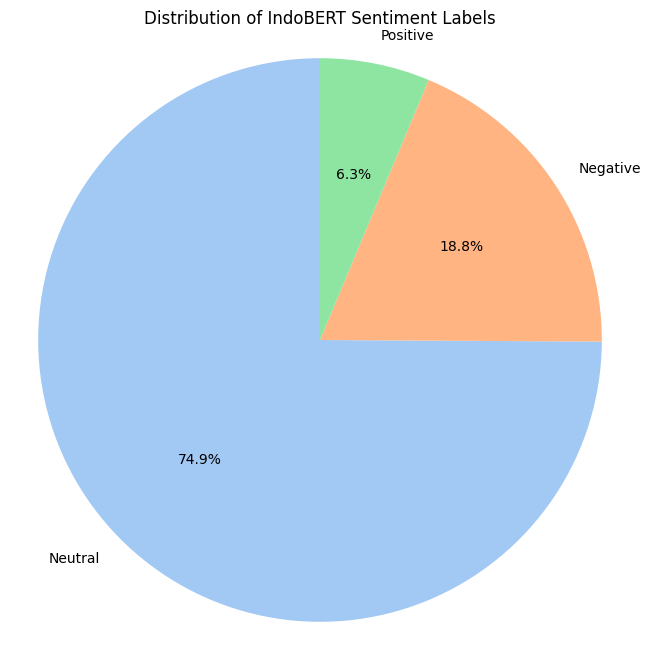

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Break("Visualizing IndoBERT Sentiment Label Distribution with Pie Chart")

# Calculate the value counts for the IndoBERT sentiment labels
sentiment_counts = df['sentiment_label'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of IndoBERT Sentiment Labels')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

##Manual Labeling

In [ ]:
import pandas as pd
import os

df_clean = df.copy()
df_clean['no'] = df_clean['conversation_id']
df_clean['full_text'] = df_clean['tweet']
df_clean = df_clean[['no', 'full_text', 'tweet', 'sentiment_label']]

path_manual = '/content/manual_ground_truth.csv'

manual_dir = os.path.dirname(path_manual);
if not os.path.exists(manual_dir):
    os.makedirs(manual_dir, exist_ok=True)
    print(f"Direktori '{manual_dir}' berhasil dibuat.")

if 'df_clean' not in locals() or df_clean is None:
    print("ERROR: Dataset utama 'df_clean' tidak ditemukan di memori!")
elif df_clean.empty:
    print("ERROR: Dataset utama 'df_clean' kosong!")
else:
    if os.path.exists(path_manual):
        df_manual = pd.read_csv(path_manual)
        print(f"Memuat progres: {len(df_manual)} data sudah ada di daftar.")
    else:
        df_manual = pd.DataFrame(columns=df_clean.columns)
        df_manual['manual_label'] = None
        print("Memulai file manual baru.")

    sudah_ada_ids = []
    if 'no' in df_manual.columns:
        sudah_ada_ids = df_manual['no'].unique()

    df_belum_label = df_clean[~df_clean['no'].isin(sudah_ada_ids)].copy()

    labeling_limit = 50
    df_to_label = df_belum_label.head(labeling_limit)

    if len(df_belum_label) == 0:
        print("Luar biasa! Semua data dari dataset utama sudah masuk ke file manual.")
    else:
        print(f"Terdeteksi {len(df_belum_label)} data baru yang menunggu dilabeli.")
        print(f"Hanya menampilkan {len(df_to_label)} data untuk pelabelan manual saat ini.")
        print("Ketik: 1 (Pos), 0 (Net), 2 (Neg) | 'stop' untuk simpan & keluar.")
        print("=" * 60)

        try:
            for i, row in df_to_label.iterrows():
                print(f"\n[No: {row['no']}]")
                print(f"TEXT: {row['full_text']}")
                print(f"Prediksi Sentimen Otomatis: {row['sentiment_label']}")

                while True:
                    user_input = input(">> Label: ").lower()

                    if user_input == 'stop':
                        raise StopIteration

                    if user_input in ['0', '1', '2']:
                        new_row = row.copy()

                        if user_input == '2':
                            new_row['manual_label'] = -1
                        else:
                            new_row['manual_label'] = int(user_input)

                        df_manual = pd.concat([df_manual, pd.DataFrame([new_row])], ignore_index=True)

                        df_manual.to_csv(path_manual, index=False)
                        break
                    else:
                        print("SALAH! Masukkan 0, 1, atau 2 saja.")

        except StopIteration:
            print("\nSesi dihentikan. Progres Anda telah aman tersimpan.")
        except Exception as e:
            print(f"\nTerjadi kesalahan selama pelabelan: {e}")
            print("Progres Anda telah aman tersimpan hingga titik terakhir.")

    total_data_source = len(df_clean) if 'df_clean' in locals() and df_clean is not None else 0
    total_terisi = df_manual['manual_label'].notna().sum() if 'df_manual' in locals() and 'manual_label' in df_manual.columns else 0

    print("\n" + "="*40)
    print(f"TOTAL PROGRESS: {total_terisi} / {total_data_source} Data")
    print(f"Lokasi: {path_manual}")
    print("="*40)

Memuat progres: 95 data sudah ada di daftar.
Terdeteksi 79486 data baru yang menunggu dilabeli.
Hanya menampilkan 50 data untuk pelabelan manual saat ini.
Ketik: 1 (Pos), 0 (Net), 2 (Neg) | 'stop' untuk simpan & keluar.

[No: 1258391827708694528]
TEXT: jujur, drpd mengharap bantuan dr pemerintah atau dr presiden.. aku lebih mengharap pandemi covid-19 cepat selesai. biar bisa kembali beraktivitas tanpa was-was
Prediksi Sentimen Otomatis: Positive
>> Label: 1

[No: 1258391766652162048]
TEXT: Untuk mendukung program Pemerintah dalam rangka menghambat penyebaran Covid-19, kami menginfokan bahwa Klinik Kecantikan dr.Estie membuka pelayanan Konsultasi Online melalui Whatsapp GRATIS
.
Jadi, tidak perlu…  https://www.instagram.com/p/B_44LaqlSzg/?igshid=8k8lqmvcuisu …
Prediksi Sentimen Otomatis: Neutral
>> Label: 0

[No: 1258391686419329024]
TEXT: Pemerintah Indonesia melalui Gugus Tugas Percepatan Penanganan COVID-19 mencatat jumlah kasus sembuh COVID-19 per hari ini Senin (4/5) pukul 12.00 WI



⚙️ VISUALIZING MANUAL LABEL DISTRIBUTION WITH PIE CHART


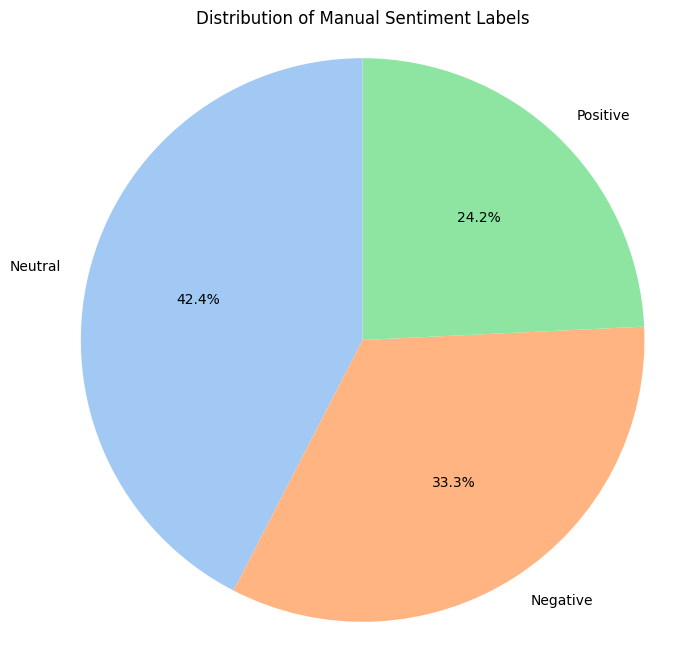

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_manual is available from the previous manual labeling cell
if 'df_manual' in locals() and not df_manual.empty:
    Break("Visualizing Manual Label Distribution with Pie Chart")

    label_map = {
        1: 'Positive',
        0: 'Neutral',
        -1: 'Negative' # Assuming -1 was used for '2 (Neg)'
    }

    manual_sentiment_counts = df_manual['manual_label'].dropna().map(label_map).value_counts()

    # Create a pie chart
    if not manual_sentiment_counts.empty:
        plt.figure(figsize=(8, 8))
        plt.pie(manual_sentiment_counts,
                labels=manual_sentiment_counts.index,
                autopct='%1.1f%%',
                startangle=90,
                colors=sns.color_palette('pastel'))
        plt.title('Distribution of Manual Sentiment Labels')
        plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
        plt.show()
    else:
        print("Tidak ada data label manual yang tersedia untuk divisualisasikan.")
elif 'df_manual' not in locals():
    print("DataFrame 'df_manual' tidak ditemukan. Pastikan sel pelabelan manual telah dijalankan.")
else:
    print("DataFrame 'df_manual' kosong. Tidak ada data label manual untuk divisualisasikan.")

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

if 'df_manual' not in locals() or df_manual.empty or 'manual_label' not in df_manual.columns:
    print("DataFrame df_manual tidak ditemukan atau kosong, atau kolom 'manual_label' tidak ada.")
    print("Silakan jalankan kembali sel pelabelan manual terlebih dahulu.")
else:
    Break("Menganalisis Akurasi Sentimen IndoBERT vs. Manual")

    comparison_df = pd.merge(
        df_manual[['no', 'manual_label']],
        df[['conversation_id', 'sentiment_label']],
        left_on='no',
        right_on='conversation_id',
        how='inner'
    )

    comparison_df.drop(columns=['conversation_id'], inplace=True);

    label_mapping = {
        1: 'Positive',
        0: 'Neutral',
        -1: 'Negative'
    }

    comparison_df['manual_label_str'] = comparison_df['manual_label'].map(label_mapping)

    comparison_df.dropna(subset=['manual_label_str', 'sentiment_label'], inplace=True);

    if not comparison_df.empty:
        y_true = comparison_df['manual_label_str']
        y_pred = comparison_df['sentiment_label']

        accuracy = accuracy_score(y_true, y_pred)
        print(f"Jumlah sampel yang dibandingkan: {len(y_true)}")
        print(f"Akurasi (IndoBERT vs. Manual): {accuracy:.2f}")

        print("\nLaporan Klasifikasi:")
        print(classification_report(y_true, y_pred, zero_division=0))

    else:
        print("Tidak ada data yang tumpang tindih antara label manual dan label IndoBERT untuk dibandingkan.")



⚙️ MENGANALISIS AKURASI SENTIMEN INDOBERT VS. MANUAL
Jumlah sampel yang dibandingkan: 107
Akurasi (IndoBERT vs. Manual): 0.70

Laporan Klasifikasi:
              precision    recall  f1-score   support

    Negative       0.84      0.79      0.81        33
     Neutral       0.65      0.88      0.75        50
    Positive       0.62      0.21      0.31        24

    accuracy                           0.70       107
   macro avg       0.70      0.63      0.62       107
weighted avg       0.70      0.70      0.67       107





⚙️ MENAMPILKAN CONFUSION MATRIX


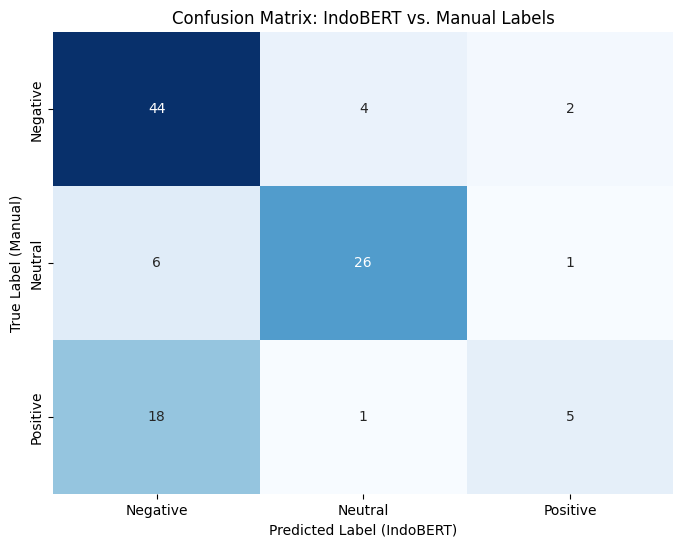

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

if 'y_true' in locals() and 'y_pred' in locals() and not y_true.empty:
    Break("Menampilkan Confusion Matrix")

    # Generate the confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=list(y_true.unique()))

    # Get unique labels in sorted order to ensure consistent plotting
    labels = sorted(y_true.unique())

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=labels,
                yticklabels=labels,
                cbar=False)
    plt.xlabel('Predicted Label (IndoBERT)')
    plt.ylabel('True Label (Manual)')
    plt.title('Confusion Matrix: IndoBERT vs. Manual Labels')
    plt.show()
elif 'df_manual' not in locals():
    print("DataFrame 'df_manual' tidak ditemukan. Pastikan sel pelabelan manual dan analisis akurasi telah dijalankan.")
else:
    print("Tidak ada data yang cukup untuk membuat confusion matrix. Pastikan ada data yang tumpang tindih antara label manual dan label IndoBERT.")

#Evaluasi

In [ ]:
import pandas as pd
import os
import ast

csv_filename = 'stemmed_tweets_checkpoint.csv'

current_stemmed_tweet_series = None

if 'stemmed_tweet_df' in globals() and isinstance(globals()['stemmed_tweet_df'], pd.Series):
    current_stemmed_tweet_series = globals()['stemmed_tweet_df']
    print("'stemmed_tweet_df' found in memory.")
elif os.path.exists(csv_filename):
    print(f"'{csv_filename}' not found in memory, attempting to load from CSV...")
    try:
        loaded_series_str = pd.read_csv(csv_filename, header=None, skiprows=1).iloc[:, 0]
        current_stemmed_tweet_series = loaded_series_str.apply(ast.literal_eval)
        print(f"Stemmed tweets loaded successfully from '{csv_filename}'.")
    except Exception as e:
        print(f"Error loading or processing '{csv_filename}': {e}. Cannot proceed with creating processed text.")
        current_stemmed_tweet_series = None
else:
    print(f"Error: '{csv_filename}' not found on disk and 'stemmed_tweet_df' not in memory. Cannot proceed.")
    current_stemmed_tweet_series = None

if current_stemmed_tweet_series is not None:
    if len(current_stemmed_tweet_series) == len(df):
        current_stemmed_tweet_series.index = df.index
    else:
        print(f"Warning: Length mismatch between current df ({len(df)}) and stemmed data ({len(current_stemmed_tweet_series)}). Reindexing to align.")
        current_stemmed_tweet_series = current_stemmed_tweet_series.reindex(df.index, fill_value=[])

    df['stemmed_tokens'] = current_stemmed_tweet_series

    df['processed_text_for_sentiment'] = df['stemmed_tokens'].apply(
        lambda x: ' '.join(x) if isinstance(x, list) and x else ''
    )
    print("Columns 'stemmed_tokens' and 'processed_text_for_sentiment' have been created/updated in df.")
else:
    print("Failed to prepare 'processed_text_for_sentiment' as stemmed data is unavailable.")

print("\nSample of 'processed_text_for_sentiment' after update:")
display(df[['tweet', 'processed_text_for_sentiment']].head())

'stemmed_tweets_checkpoint.csv' not found in memory, attempting to load from CSV...
Stemmed tweets loaded successfully from 'stemmed_tweets_checkpoint.csv'.
Columns 'stemmed_tokens' and 'processed_text_for_sentiment' have been created/updated in df.

Sample of 'processed_text_for_sentiment' after update:


,tweet,processed_text_for_sentiment
0,https://bit.ly/2L6CcbB | Seharusnya saat ini...,perintah lampung bantu mahasiswa deras donasi ...
1,Klo kata gw Pemerintah tuh lagi menerapkan Her...,kalo gue perintah tuh terap herd immunity mamp...
2,Saat ini yang bisa saya lakukan hanya menyiapk...,laku makan buka sahur kepala keluarga dampak c...
3,"Satu Warga Positif Corona, Bupati: Kondisi ini...",warga positif corona bupati kondisi tuntut sam...
4,"emosi bgt, lg kondisi begini gue disuruh liput...",emosi banget kondisi gue suruh liput covid dos...


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import warnings

warnings.filterwarnings('ignore')

valid_labels = ['Positive', 'Neutral', 'Negative']
df_filtered = df[df['sentiment_label'].isin(valid_labels)].copy()
df_filtered['processed_text_for_sentiment'] = df_filtered['processed_text_for_sentiment'].fillna('').str.strip()
df_filtered = df_filtered[df_filtered['processed_text_for_sentiment'] != ""]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df_filtered['processed_text_for_sentiment'],
    df_filtered['sentiment_label'],
    test_size=0.2,
    random_state=42,
    stratify=df_filtered['sentiment_label']
)

vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

print("Sedang melatih SVM dengan Kernel: RBF...")
model = SVC(kernel='rbf', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Hasil RBF: Akurasi = {acc:.4f}")
print("-" * 30)

print("\nProses Selesai!")

Sedang melatih SVM dengan Kernel: RBF...
Hasil RBF: Akurasi = 0.8139
------------------------------

Proses Selesai!


#Word Cloud



⚙️ VISUALISASI WORD CLOUD BERDASARKAN SENTIMEN


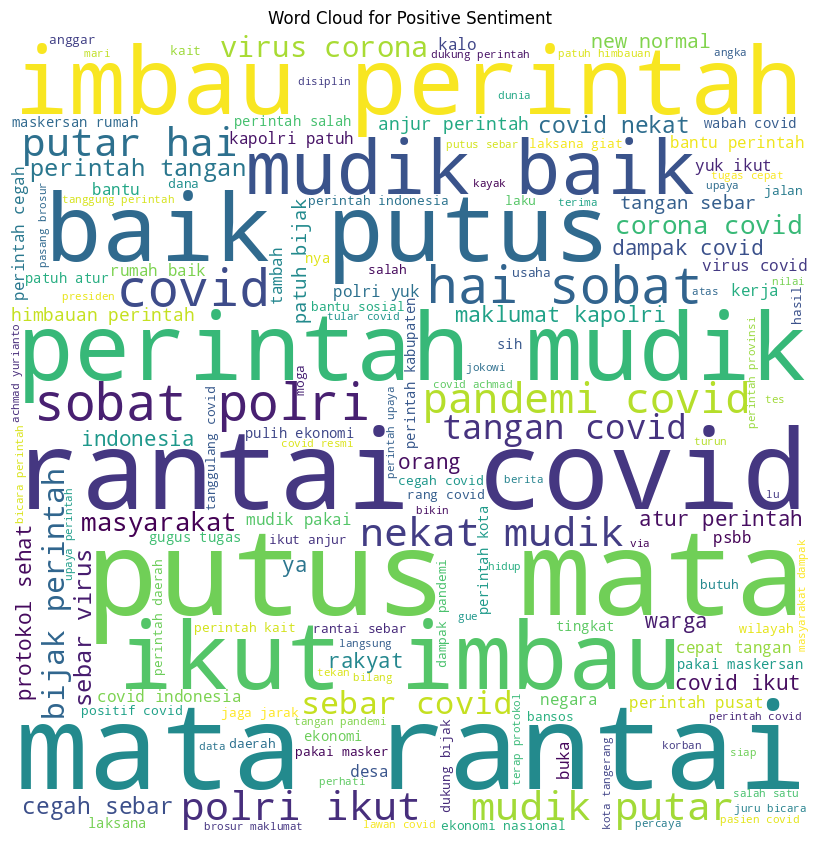

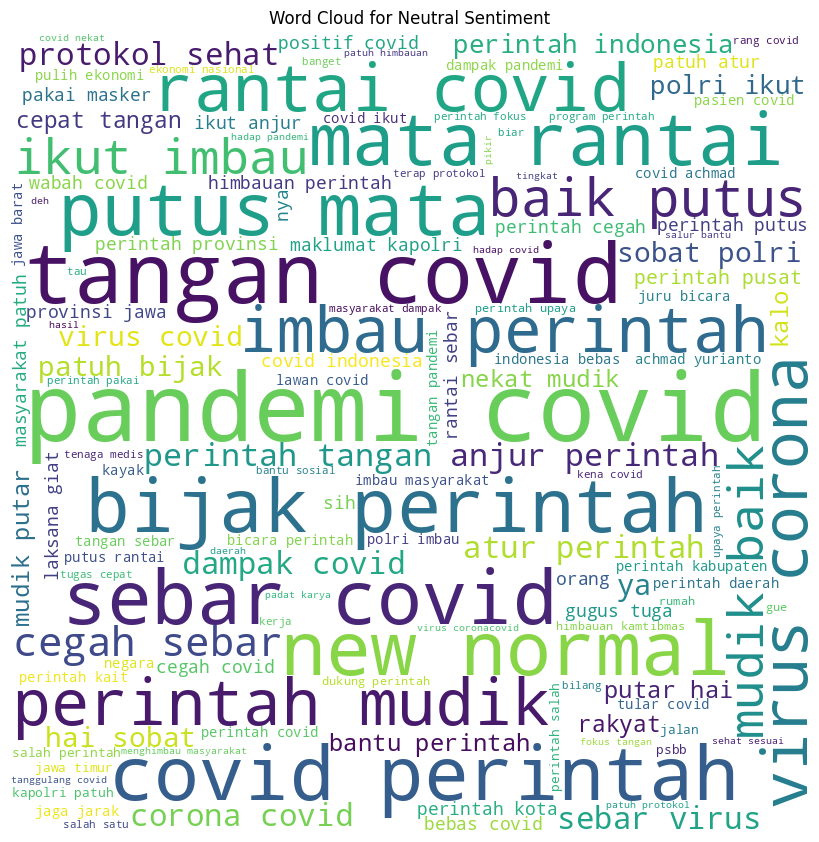

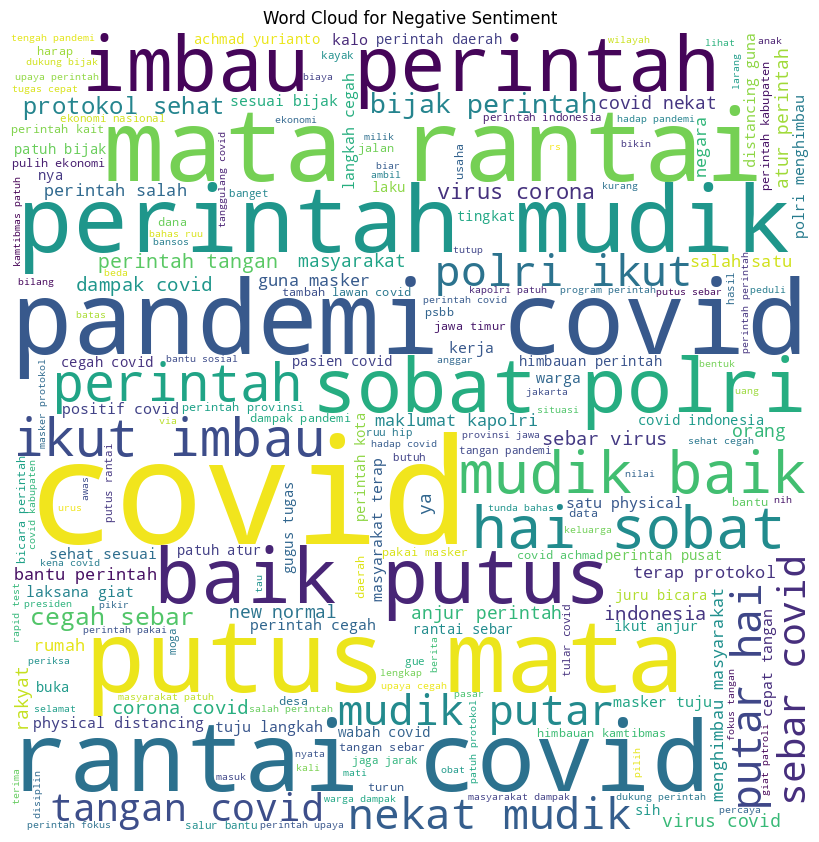

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

Break("Visualisasi Word Cloud Berdasarkan Sentimen")

sentiment_categories = ['Positive', 'Neutral', 'Negative']
colors = {'Positive': 'green', 'Neutral': 'blue', 'Negative': 'red'}

for sentiment in sentiment_categories:
    sentiment_df = df[df['sentiment_label'] == sentiment]

    all_words_sentiment = ' '.join([text for text in sentiment_df['processed_text_for_sentiment'] if isinstance(text, str) and text.strip() != ''])

    if not all_words_sentiment:
        print(f"Tidak ada teks yang cukup untuk membuat Word Cloud untuk sentimen: {sentiment}")
    else:
        wordcloud = WordCloud(width = 800, height = 800,
                              background_color ='white',
                              min_font_size = 10).generate(all_words_sentiment)

        plt.figure(figsize = (8, 8), facecolor = None)
        plt.imshow(wordcloud)
        plt.axis("off")
        plt.tight_layout(pad = 0)
        plt.title(f'Word Cloud for {sentiment} Sentiment')
        plt.show()

# Topic Modeling (Latent Dirichlet Allocation - LDA)

In [ ]:
!pip install gensim

In [ ]:
import gensim
from gensim import corpora
from sklearn.feature_extraction.text import CountVectorizer

Break("Preparing Data for LDA Topic Modeling")

corpus_for_lda = [tokens for tokens in df['stemmed_tokens'] if isinstance(tokens, list) and tokens]

dictionary = corpora.Dictionary(corpus_for_lda)

dictionary.filter_extremes(no_below=5, no_above=0.5)

bow_corpus = [dictionary.doc2bow(doc) for doc in corpus_for_lda]

print(f"Number of unique tokens: {len(dictionary)}")
print(f"Number of documents (tweets) for LDA: {len(bow_corpus)}")



⚙️ PREPARING DATA FOR LDA TOPIC MODELING
Number of unique tokens: 6112
Number of documents (tweets) for LDA: 45949


In [ ]:
Break("Running LDA Model")

num_topics = 5
lda_model = gensim.models.LdaMulticore(bow_corpus, num_topics=num_topics, id2word=dictionary, passes=10, workers=2, random_state=42)

print("Top words for each topic:")
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic {idx}: {topic}")

def get_dominant_topic(ldamodel, corpus, texts):
    sent_topics_df = pd.DataFrame()

    for i, row_list in enumerate(ldamodel[corpus]):
        row = row_list[0] if ldamodel.per_word_topics else row_list
        row = sorted(row, key=lambda x: (x[1]), reverse=True)
        for j, (topic_num, prop_topic) in enumerate(row):
            if j == 0:
                wp = ldamodel.show_topic(topic_num)
                topic_keywords = ", ".join([word for word, prop in wp])
                sent_topics_df = pd.concat([
                    sent_topics_df,
                    pd.DataFrame([{'Dominant_Topic': int(topic_num), 'Perc_Contribution': round(prop_topic, 4), 'Topic_Keywords': topic_keywords}])
                ], ignore_index=True)
            else:
                break
    return sent_topics_df

df_topic_sents_keywords = get_dominant_topic(lda_model, bow_corpus, df['processed_text_for_sentiment'].tolist())

original_indices = [idx for idx, tokens in zip(df.index, df['stemmed_tokens']) if isinstance(tokens, list) and tokens]
df_topic_sents_keywords.index = original_indices

df = df.drop(columns=['Dominant_Topic', 'Perc_Contribution', 'Topic_Keywords'], errors='ignore')
df = df.merge(df_topic_sents_keywords, left_index=True, right_index=True, how='left')

Break("Sample Tweets with Dominant Topic")
display(df[['tweet', 'sentiment_label', 'Dominant_Topic', 'Perc_Contribution', 'Topic_Keywords']].head())

Break("Topic Distribution")
print(df['Dominant_Topic'].value_counts())



⚙️ RUNNING LDA MODEL
Top words for each topic:
Topic 0: 0.030*"pandemi" + 0.023*"dampak" + 0.022*"bantu" + 0.018*"tangan" + 0.016*"masyarakat" + 0.015*"ekonomi" + 0.010*"kota" + 0.010*"normal" + 0.010*"program" + 0.009*"provinsi"
Topic 1: 0.054*"sebar" + 0.041*"cegah" + 0.037*"patuh" + 0.030*"virus" + 0.029*"protokol" + 0.026*"sehat" + 0.026*"himbauan" + 0.025*"bijak" + 0.025*"masyarakat" + 0.021*"laksana"
Topic 2: 0.020*"normal" + 0.017*"new" + 0.015*"ya" + 0.012*"pandemi" + 0.012*"rakyat" + 0.012*"indonesia" + 0.011*"kalo" + 0.009*"salah" + 0.009*"masyarakat" + 0.009*"orang"
Topic 3: 0.121*"putus" + 0.109*"mudik" + 0.094*"rantai" + 0.082*"mata" + 0.078*"ikut" + 0.071*"baik" + 0.063*"imbau" + 0.035*"polri" + 0.035*"sobat" + 0.034*"hai"
Topic 4: 0.028*"tangan" + 0.020*"positif" + 0.019*"corona" + 0.016*"orang" + 0.016*"pasien" + 0.015*"virus" + 0.015*"indonesia" + 0.015*"data" + 0.013*"tambah" + 0.011*"pandemi"


⚙️ SAMPLE TWEETS WITH DOMINANT TOPIC


,tweet,sentiment_label,Dominant_Topic,Perc_Contribution,Topic_Keywords
0,https://bit.ly/2L6CcbB | Seharusnya saat ini...,Neutral,0.0,0.9330,"pandemi, dampak, bantu, tangan, masyarakat, ek..."
1,Klo kata gw Pemerintah tuh lagi menerapkan Her...,Negative,2.0,0.8581,"normal, new, ya, pandemi, rakyat, indonesia, k..."
2,Saat ini yang bisa saya lakukan hanya menyiapk...,Neutral,0.0,0.6778,"pandemi, dampak, bantu, tangan, masyarakat, ek..."
3,"Satu Warga Positif Corona, Bupati: Kondisi ini...",Neutral,0.0,0.4376,"pandemi, dampak, bantu, tangan, masyarakat, ek..."
4,"emosi bgt, lg kondisi begini gue disuruh liput...",Negative,2.0,0.9465,"normal, new, ya, pandemi, rakyat, indonesia, k..."




⚙️ TOPIC DISTRIBUTION
Dominant_Topic
2.0    14002
0.0    13164
1.0     8093
4.0     6544
3.0     4146
Name: count, dtype: int64


## Interpretasi Topik LDA

Berdasarkan kata-kata kunci dari setiap topik yang dihasilkan oleh model LDA, berikut adalah interpretasi dari 5 topik:

*   **Topik 0: Dampak Ekonomi dan Sosial Pandemi**
    *   Kata kunci seperti 'pandemi', 'dampak', 'bantu', 'masyarakat', 'ekonomi', 'kota', 'program' menunjukkan bahwa topik ini berkaitan dengan efek pandemi secara sosial dan ekonomi, serta upaya bantuan terkait.

*   **Topik 1: Pencegahan COVID-19 dan Protokol Kesehatan**
    *   Kata kunci seperti 'sebar', 'cegah', 'patuh', 'virus', 'protokol', 'sehat', 'himbauan', 'bijak', 'laksana' dengan jelas mengarah pada diskusi seputar pencegahan penyebaran virus dan kepatuhan terhadap protokol kesehatan.

*   **Topik 2: Persepsi Publik dan New Normal**
    *   Kata kunci seperti 'normal', 'new', 'rakyat', 'indonesia', 'kalo', 'salah', 'orang' mengindikasikan percakapan tentang 'normal baru', opini publik, dan kemungkinan kritik atau diskusi tentang pendekatan pemerintah terhadap pandemi.

*   **Topik 3: Pembatasan dan Kepatuhan Publik (misalnya Larangan Mudik)**
    *   Kata kunci yang kuat seperti 'putus', 'mudik', 'rantai', 'mata', 'ikut', 'imbau', 'polri' menyiratkan diskusi yang berpusat pada pemutusan rantai penularan, khususnya terkait larangan 'mudik' dan seruan untuk kepatuhan publik.

*   **Topik 4: Kasus COVID-19 dan Pelaporan Data**
    *   Kata kunci seperti 'tangan', 'positif', 'corona', 'orang', 'pasien', 'virus', 'indonesia', 'data', 'tambah' berkaitan dengan pelaporan kasus COVID-19, pasien positif, dan keseluruhan penyebaran virus di Indonesia.